In [62]:
import torch
print(torch.cuda.is_available()) # Should print True
print(torch.cuda.get_device_name(0)) # Should print "NVIDIA GeForce RTX 3050 Laptop GPU"

True
NVIDIA GeForce RTX 3050 Laptop GPU


In [63]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import random
from PIL import Image

# 1. Define Base Transform (No Augmentation)
base_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.Grayscale(num_output_channels=1), # Convert to grayscale after resize
    transforms.ToTensor(),
])

# 2. Define Augmentation Transform for CT Scans
aug_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.Grayscale(num_output_channels=1), # Convert to grayscale after resize
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
])

# 3. Normalization Transform (applied after to tensors)
normalize_transform = transforms.Normalize(mean=[0.5], std=[0.5])

# For visualization purposes, we use datasets WITHOUT normalization so they display correctly
base_dataset = datasets.ImageFolder(root='Data/train', transform=base_transform)

# Actual training datasets WITH augmentation AND normalization
train_transform = transforms.Compose([aug_transform, normalize_transform])
val_test_transform = transforms.Compose([base_transform, normalize_transform])

train_dataset_augmented = datasets.ImageFolder(root='Data/train', transform=train_transform)
valid_dataset = datasets.ImageFolder(root='Data/valid', transform=val_test_transform)
test_dataset = datasets.ImageFolder(root='Data/test', transform=val_test_transform)

batch_size = 16

train_loader = DataLoader(train_dataset_augmented, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


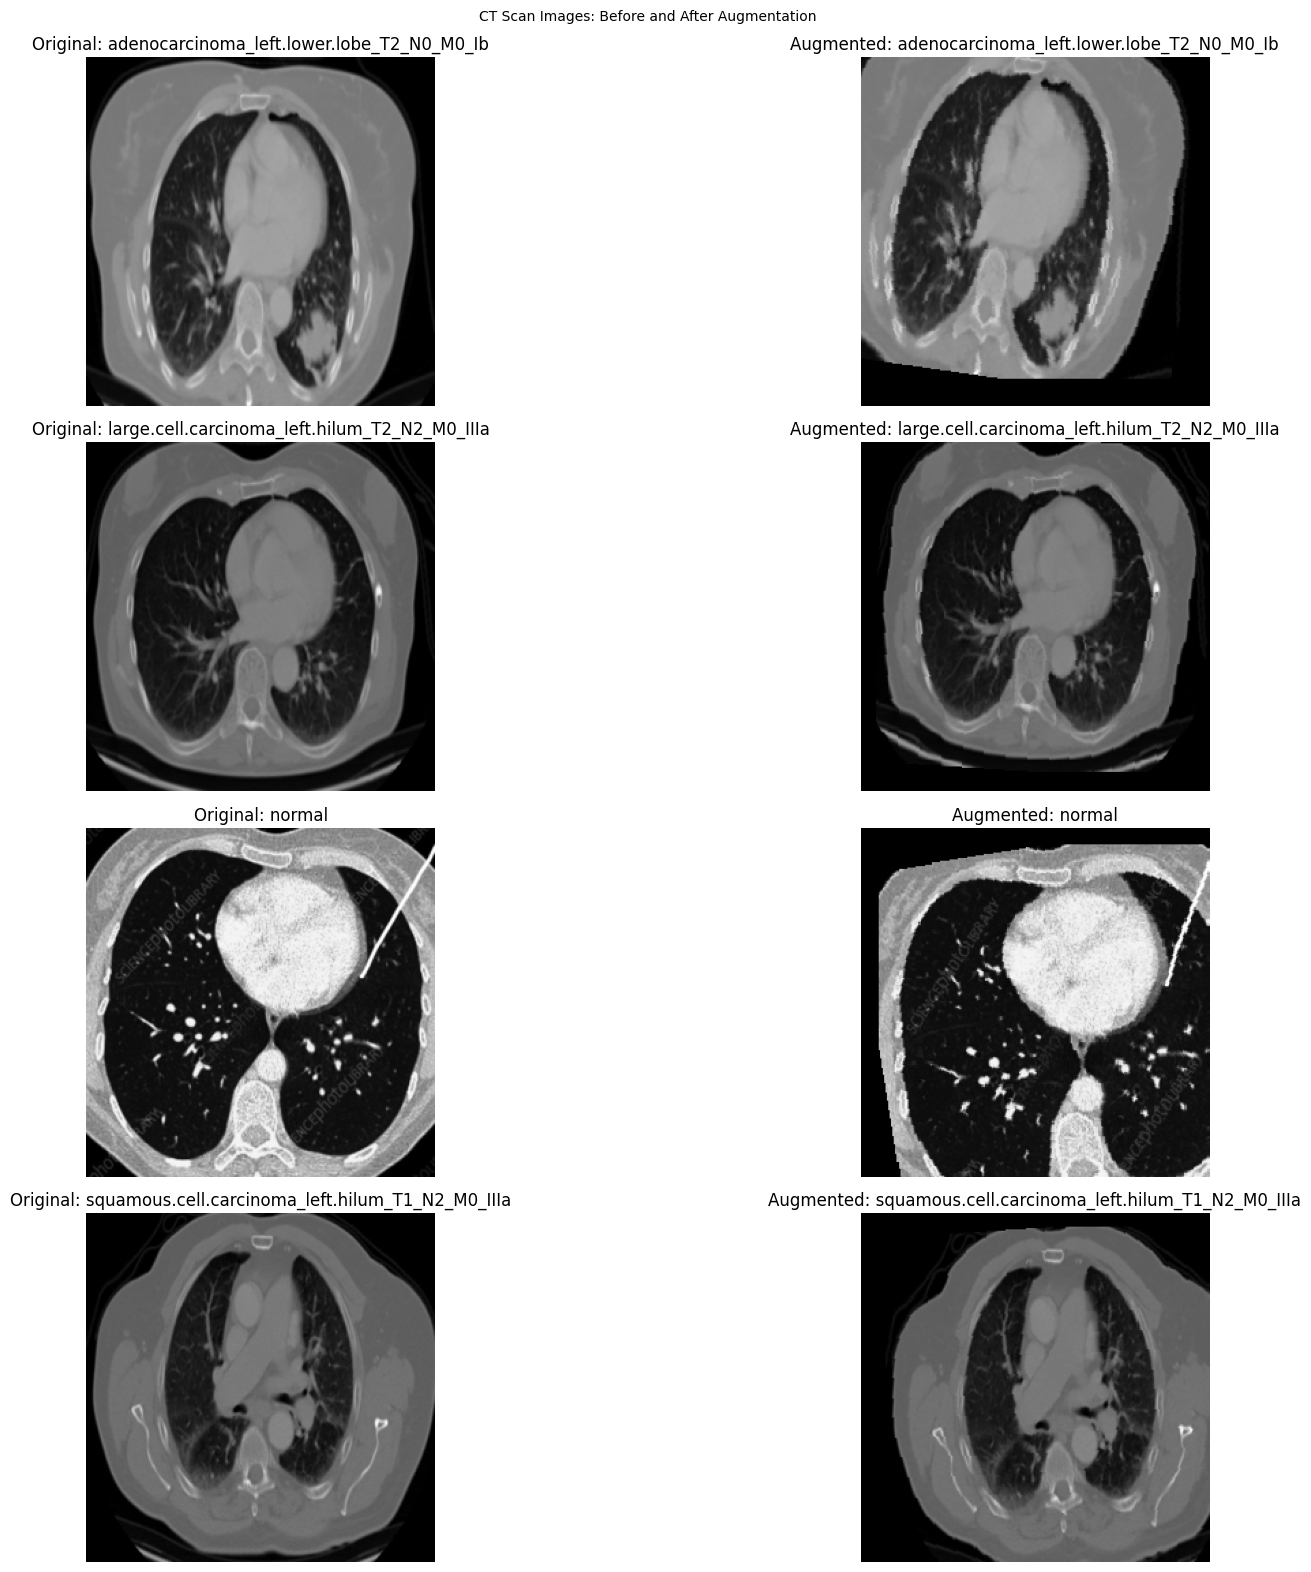

In [64]:
def visualize_augmentations(base_ds, aug_transform, num_samples_per_class=1):
    classes = base_ds.classes
    num_classes = len(classes)
    
    fig, axes = plt.subplots(num_classes, 2, figsize=(20, 4 * num_classes))
    fig.suptitle('CT Scan Images: Before and After Augmentation', fontsize=10)
    
    for i, cls_name in enumerate(classes):
        # Find a random sample from this class
        cls_idx = base_ds.class_to_idx[cls_name]
        indices = [idx for idx, (_, label) in enumerate(base_ds.samples) if label == cls_idx]
        sample_idx = random.choice(indices)
        
        # Get the original PIL image to apply both transforms identically if needed
        img_path = base_ds.samples[sample_idx][0]
        raw_img = Image.open(img_path).convert('RGB')
        
        # Apply transforms (we don't apply normalization here so they display nicely)
        base_tensor = base_transform(raw_img)
        aug_tensor = aug_transform(raw_img)
        
        # Convert to numpy for matplotlib (C, H, W) -> (H, W, C)
        base_np = np.transpose(base_tensor.numpy(), (1, 2, 0))
        aug_np = np.transpose(aug_tensor.numpy(), (1, 2, 0))
        
        # Plot Base (Original)
        ax_base = axes[i, 0] if num_classes > 1 else axes[0]
        ax_base.imshow(base_np, cmap='gray')
        ax_base.set_title(f'Original: {cls_name}')
        ax_base.axis('off')
        
        # Plot Augmented
        ax_aug = axes[i, 1] if num_classes > 1 else axes[1]
        ax_aug.imshow(aug_np, cmap='gray')
        ax_aug.set_title(f'Augmented: {cls_name}')
        ax_aug.axis('off')
        
    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    plt.show()

# Run the visualization
visualize_augmentations(base_dataset, aug_transform)


In [65]:
import torch.nn as nn
import torch.optim as optim
import torch
from torch.optim import lr_scheduler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Define AlexNet Architecture from Scratch
class CustomAlexNet(nn.Module):
    def __init__(self, num_classes=4):
        super(CustomAlexNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(8),
            nn.Conv2d(8, 8, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(8, 16, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(16),
            nn.Conv2d(16, 16, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(16, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
        )

        self.classifier = nn.Sequential(
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.9),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

# Instantiate the model
model = CustomAlexNet(num_classes=4)
model = model.to(device)

# Define Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0001)

scheduler = lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

Using device: cuda


In [66]:
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import os

num_epochs           = 80
checkpoint_filepath  = 'Exact_best_model.pth'
best_val_accuracy    = 0.0

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(num_epochs):
    # ---- Training Phase ----
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    loop = tqdm(train_loader, leave=True, desc=f'Epoch [{epoch+1}/{num_epochs}]')
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted  = torch.max(outputs, 1)
        total        += labels.size(0)
        correct      += (predicted == labels).sum().item()
        loop.set_postfix(loss=f'{loss.item():.4f}', acc=f'{100.*correct/total:.2f}%')

    scheduler.step()

    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc  = 100. * correct / total

    # ---- Validation Phase ----
    model.eval()
    val_loss = 0.0
    correct_val, total_val = 0, 0

    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs   = model(images)
            loss      = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val   += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / len(valid_loader.dataset)
    epoch_val_acc  = 100. * correct_val / total_val

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accs.append(epoch_train_acc)
    val_accs.append(epoch_val_acc)

    print(f'Epoch {epoch+1}/{num_epochs}  |  '
          f'Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}%  |  '
          f'Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%')

    # ---- ModelCheckpoint: save best weights ----
    if epoch_val_acc > best_val_accuracy:
        best_val_accuracy = epoch_val_acc
        torch.save(model.state_dict(), checkpoint_filepath)
        print(f'  >> Val accuracy improved to {epoch_val_acc:.2f}%. Best model saved.')

print(f'\\nTraining complete. Best Validation Accuracy: {best_val_accuracy:.2f}%')


Epoch [1/80]: 100%|██████████| 39/39 [00:05<00:00,  7.11it/s, acc=34.26%, loss=1.2965]


Epoch 1/80  |  Train Loss: 1.9676, Train Acc: 34.26%  |  Val Loss: 1.2039, Val Acc: 40.28%
  >> Val accuracy improved to 40.28%. Best model saved.


Epoch [2/80]: 100%|██████████| 39/39 [00:04<00:00,  8.18it/s, acc=41.11%, loss=1.2904]


Epoch 2/80  |  Train Loss: 1.2540, Train Acc: 41.11%  |  Val Loss: 1.0186, Val Acc: 34.72%


Epoch [3/80]: 100%|██████████| 39/39 [00:05<00:00,  7.65it/s, acc=36.22%, loss=1.3639]


...

Epoch 78/80  |  Train Loss: 1.1426, Train Acc: 41.11%  |  Val Loss: 0.9701, Val Acc: 50.00%


Epoch [79/80]: 100%|██████████| 39/39 [00:05<00:00,  7.40it/s, acc=36.22%, loss=1.2644]


Epoch 79/80  |  Train Loss: 1.1365, Train Acc: 36.22%  |  Val Loss: 0.9625, Val Acc: 50.00%


Epoch [80/80]: 100%|██████████| 39/39 [00:05<00:00,  7.22it/s, acc=37.19%, loss=0.8828]


Epoch 80/80  |  Train Loss: 1.1564, Train Acc: 37.19%  |  Val Loss: 0.9672, Val Acc: 50.00%
\nTraining complete. Best Validation Accuracy: 51.39%


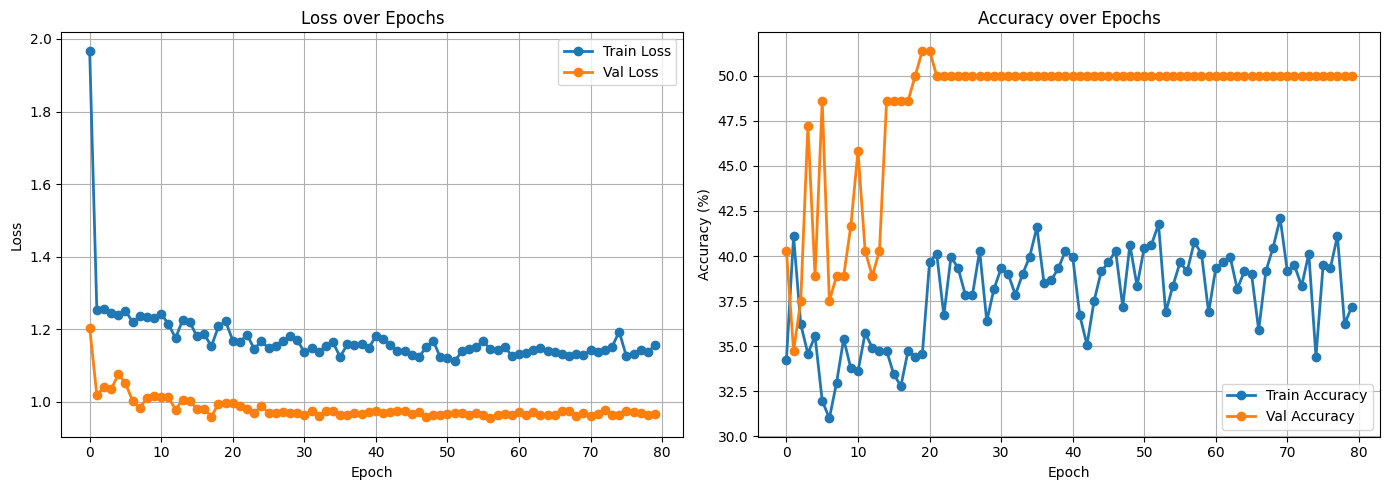

In [67]:
# ---- Training Curves ----
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', marker='o', linewidth=2)
plt.plot(val_losses,   label='Val Loss',   marker='o', linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Loss over Epochs'); plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Accuracy', marker='o', linewidth=2)
plt.plot(val_accs,   label='Val Accuracy',   marker='o', linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)')
plt.title('Accuracy over Epochs'); plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()


In [68]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. Load the Best Model
model = CustomAlexNet(num_classes=4)

checkpoint_path = 'Exact_best_model.pth'

if os.path.exists(checkpoint_path):
    state_dict = torch.load(checkpoint_path, map_location=device, weights_only=True)
    model.load_state_dict(state_dict)
    print(f"Loaded best model from {checkpoint_path}")
else:
    print(f"Warning: {checkpoint_path} not found. Using current model weights.")

model.to(device)
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 2. Calculate Metrics
test_acc = accuracy_score(all_labels, all_preds)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")

class_names = test_dataset.classes

# 3. Compute Per-Class Specificity from Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

def per_class_specificity(cm):
    specificities = []
    for i in range(len(cm)):
        TN = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        FP = cm[:, i].sum() - cm[i, i]
        spec = TN / (TN + FP) if (TN + FP) > 0 else 0.0
        specificities.append(spec)
    return np.array(specificities)

specificities = per_class_specificity(cm)

# 4. Build and Print Enhanced Classification Report
report_dict = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)

# Calculate weighted and macro average specificity
support = np.array([report_dict[c]['support'] for c in class_names])
total   = support.sum()

macro_spec    = specificities.mean()
weighted_spec = (specificities * support).sum() / total

# Print the table
header = f"{'':>20}  {'precision':>9}  {'recall':>6}  {'specificity':>11}  {'f1-score':>8}  {'support':>7}"
print("\nClassification Report with Specificity:")
print(header)
print()

for i, cls in enumerate(class_names):
    r = report_dict[cls]
    print(f"{cls:>20}  {r['precision']:>9.2f}  {r['recall']:>6.2f}  "
          f"{specificities[i]:>11.2f}  {r['f1-score']:>8.2f}  {int(r['support']):>7}")

print()
print(f"{'accuracy':>20}  {'':>9}  {'':>6}  {'':>11}  {report_dict['accuracy']:>8.2f}  {int(total):>7}")
print(f"{'macro avg':>20}  {report_dict['macro avg']['precision']:>9.2f}  "
      f"{report_dict['macro avg']['recall']:>6.2f}  {macro_spec:>11.2f}  "
      f"{report_dict['macro avg']['f1-score']:>8.2f}  {int(total):>7}")
print(f"{'weighted avg':>20}  {report_dict['weighted avg']['precision']:>9.2f}  "
      f"{report_dict['weighted avg']['recall']:>6.2f}  {weighted_spec:>11.2f}  "
      f"{report_dict['weighted avg']['f1-score']:>8.2f}  {int(total):>7}")



Loaded best model from Exact_best_model.pth

Test Accuracy: 56.19%

Classification Report with Specificity:
                      precision  recall  specificity  f1-score  support

      adenocarcinoma       0.48    0.95         0.36      0.64      120
large.cell.carcinoma       0.50    0.02         1.00      0.04       51
              normal       1.00    1.00         1.00      1.00       54
squamous.cell.carcinoma       0.40    0.09         0.95      0.15       90

            accuracy                                      0.56      315
           macro avg       0.59    0.51         0.83      0.45      315
        weighted avg       0.55    0.56         0.74      0.46      315


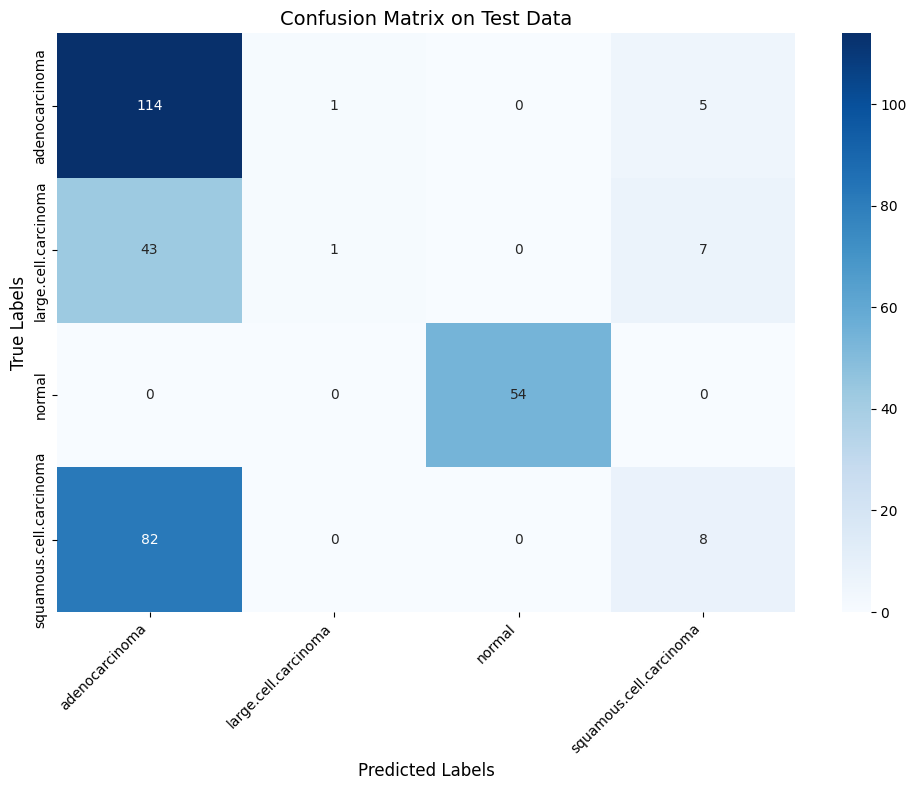

In [69]:
# 3. Plot Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.title('Confusion Matrix on Test Data', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

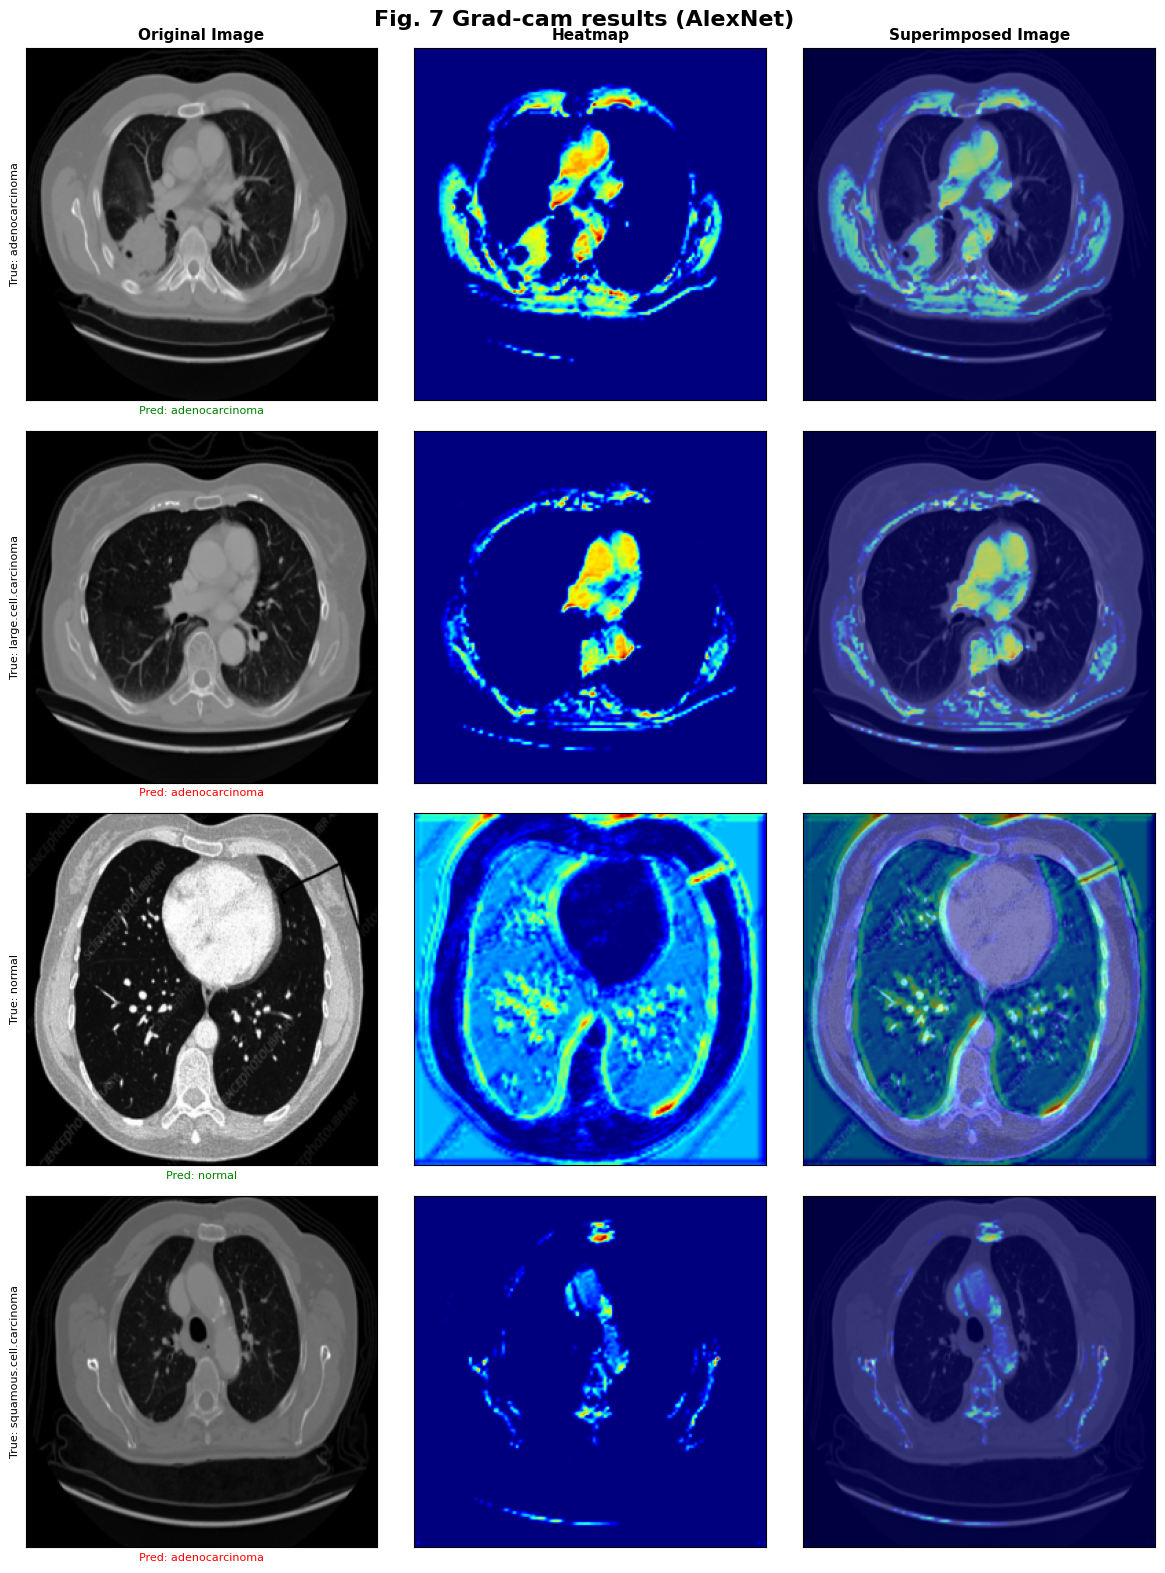

In [70]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
import random

# ---------------------------------------------------------------
# Grad-CAM — Fixed for inplace=True ReLU compatibility
# Gradients are captured via tensor.register_hook() on the
# forward activation output, bypassing the inplace ReLU conflict.
# ---------------------------------------------------------------

class GradCAM:
    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        input_tensor = input_tensor.unsqueeze(0).to(device)

        activations = []
        gradients   = []

        # Forward hook: store activations AND register a gradient hook on them
        def forward_hook(module, input, output):
            # Clone to avoid inplace-ReLU conflict
            out = output.clone()
            activations.append(out)
            out.register_hook(lambda grad: gradients.append(grad))
            return out  # return the clone so inplace ops won't affect our copy

        handle = self.target_layer.register_forward_hook(forward_hook)

        # Forward pass
        output = self.model(input_tensor)
        handle.remove()

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        # Backward pass for target class
        self.model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0][class_idx] = 1
        output.backward(gradient=one_hot)

        # GAP the gradients -> channel weights
        if not gradients:
            return np.zeros((8, 8)), class_idx  # fallback if hook missed
        weights = gradients[0].mean(dim=[2, 3], keepdim=True)  # (1, C, 1, 1)

        # Weighted sum of activation maps
        cam = (weights * activations[0]).sum(dim=1, keepdim=True)  # (1,1,H,W)
        cam = F.relu(cam)

        cam = cam.squeeze().cpu().detach().numpy()
        cam -= cam.min()
        if cam.max() > 0:
            cam /= cam.max()

        return cam, class_idx


def overlay_gradcam(img_tensor, cam, alpha=0.5):
    # Take channel 0 (all 3 channels identical for grayscale-as-RGB)
    img_np = img_tensor[0].cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)

    cam_resized = np.array(Image.fromarray(cam).resize(
        (img_np.shape[1], img_np.shape[0]), Image.BILINEAR))

    heatmap  = cm.jet(cam_resized)[..., :3]
    img_rgb  = np.stack([img_np]*3, axis=-1)
    overlay  = np.clip(alpha * heatmap + (1 - alpha) * img_rgb, 0, 1)
    return img_np, cam_resized, overlay


# Target layer: last Conv2d in features block before MaxPool
# CustomAlexNet.features index 10 = Conv2d(384->256) — the LAST conv layer
target_layer = model.features[10]
gradcam = GradCAM(model, target_layer)

class_names = test_dataset.classes
num_classes  = len(class_names)

fig, axes = plt.subplots(num_classes, 3, figsize=(12, 4 * num_classes))
fig.suptitle('Fig. 7 Grad-cam results (AlexNet)', fontsize=16, fontweight='bold')

for col, title in enumerate(['Original Image', 'Heatmap', 'Superimposed Image']):
    axes[0, col].set_title(title, fontsize=11, fontweight='bold')

for cls_idx, cls_name in enumerate(class_names):
    indices    = [i for i, (_, lbl) in enumerate(test_dataset.samples) if lbl == cls_idx]
    sample_idx = random.choice(indices)
    img_tensor, label = test_dataset[sample_idx]

    cam, pred_idx = gradcam.generate(img_tensor)
    pred_name = class_names[pred_idx]

    orig, heatmap_np, overlay = overlay_gradcam(img_tensor, cam)

    row = axes[cls_idx]
    row[0].imshow(orig, cmap='gray')
    row[0].set_ylabel(f'True: {cls_name}', fontsize=8)
    row[0].set_xlabel(f'Pred: {pred_name}', fontsize=8,
                      color='green' if pred_idx == cls_idx else 'red')
    row[1].imshow(heatmap_np, cmap='jet')
    
    row[2].imshow(overlay)
    

    for ax in row:
        ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

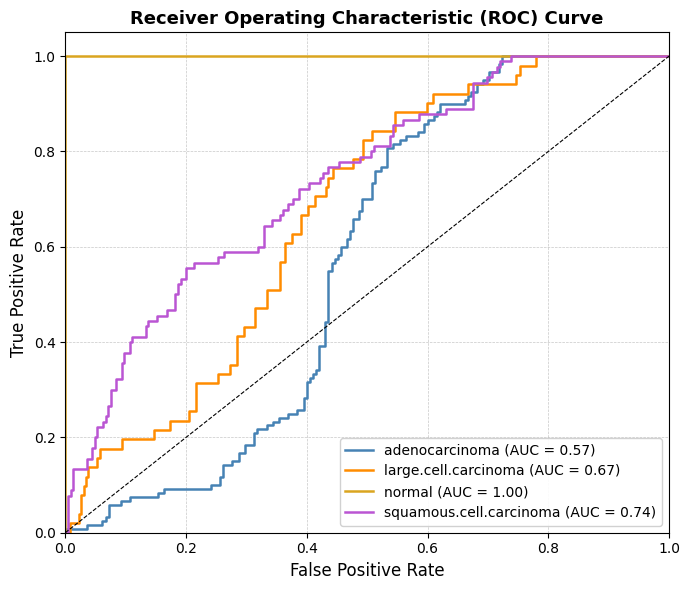

In [71]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class_names = test_dataset.classes  # ['Adenocarcinoma', 'Large Cell Carcinoma', 'Normal', 'Squamous Cell Cinoma']
n_classes = len(class_names)

model.eval()
all_probs  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)   # convert logits → probabilities
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs  = np.array(all_probs)                          # (N, 4)
all_labels = np.array(all_labels)                         # (N,)

# Binarize labels  →  shape (N, 4)
all_labels_bin = label_binarize(all_labels, classes=list(range(n_classes)))

# ── Compute ROC & AUC per class ──────────────────────────────────────────────
fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# ── Plot ─────────────────────────────────────────────────────────────────────
colors = ['steelblue', 'darkorange', 'goldenrod', 'mediumorchid']

fig, ax = plt.subplots(figsize=(7, 6))

for i, (cls, color) in enumerate(zip(class_names, colors)):
    ax.plot(fpr[i], tpr[i], color=color, lw=1.8,
            label=f'{cls} (AUC = {roc_auc[i]:.2f})')

# Diagonal reference line (random classifier)
ax.plot([0, 1], [0, 1], 'k--', lw=0.8)

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()